# Export raw mean waveforms

Per-unit **raw mean waveform** (peak channel, native length & amplitude, **not** flipped / cropped /
normalized) for sending to another cell-type classifier. 256 samples at 100 kHz = 2.56 ms.

Output: `outputs/celltype/mean_waveforms_raw_<region>.csv` — one row/unit: identity + metadata +
our labels + the 256 samples `w000..w255`. Also carries our labels (`wf_group` antimode,
`acg_type`, `wavemap_2class`) so the other method can be benchmarked against ours.

In [1]:
# [0.1] config
import sys, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
PROJECT = Path.cwd()                          # run from E:\SBCAT\celltyping
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from celltyping.features import build_unit_features
from celltyping.classify import assign_narrow_broad

DATASET   = '000673'
DATA_ROOT = PROJECT.parent / 'data' / DATASET
CT = PROJECT / 'outputs' / 'celltype'
SELECT_AREAS = ['hippocampus', 'amygdala']    # None = every area (fullest set)
FS_HZ = 100_000.0
REGION = '+'.join(a.lower() for a in SELECT_AREAS) if SELECT_AREAS else 'all'
print(f'{DATASET} | areas = {SELECT_AREAS}')

000673 | areas = ['hippocampus', 'amygdala']


In [2]:
# [1.1] load RAW mean waveforms (unflipped, native length/amplitude) + features
df, wfs = build_unit_features(list(sorted(DATA_ROOT.glob('sub-*/*.nwb'))), fs_hz=FS_HZ,
                              areas=SELECT_AREAS, return_waveforms=True,
                              waveform_kind='raw', verbose=False)
df = df.reset_index(drop=True)
keep = np.array([(w is not None and np.asarray(w).size > 0) for w in wfs])
df = df.loc[keep].reset_index(drop=True)
W = [np.asarray(wfs[i], dtype=float).ravel() for i in np.where(keep)[0]]
Ls = np.array([w.size for w in W])
N = int(np.bincount(Ls).argmax())             # modal sample length (256)
same = Ls == N
df = df.loc[same].reset_index(drop=True)
X = np.vstack([w for w, s in zip(W, same) if s])
print(f'{len(df)} units with a raw mean waveform | matrix X = {X.shape} ({N} samples, {N/FS_HZ*1000:.2f} ms)')

856 units with a raw mean waveform | matrix X = (856, 256) (256 samples, 2.56 ms)


In [3]:
# [1.2] attach our labels: wf_group (antimode, computed here) + acg_type / wavemap_2class (from CSVs)
grp, SPLIT_MS = assign_narrow_broad(df, method='antimode')
df['wf_group'] = grp
for csv, cols in [(CT / f'unit_labels_acg_{REGION}.csv', ['acg_type']),
                  (CT / f'unit_labels_wavemap_{REGION}.csv', ['wavemap_2class'])]:
    if csv.exists():
        lab = pd.read_csv(csv)[['unit_id'] + cols].drop_duplicates('unit_id')
        df = df.merge(lab, on='unit_id', how='left')
    else:
        for c in cols: df[c] = pd.NA
        print(f'(note) {csv.name} not found — {cols} left blank')
print('label coverage:', {c: int(df[c].notna().sum()) for c in ['wf_group', 'acg_type', 'wavemap_2class']})

label coverage: {'wf_group': 856, 'acg_type': 468, 'wavemap_2class': 856}


In [4]:
# [1.3] assemble the export table + save CSV and NPZ
META = ['unit_id', 'session_id', 'subject', 'location', 'n_spikes_wf', 'n_channels', 'inverted',
        'wf_valid', 'trough_to_peak_ms', 'half_width_ms', 'mean_rate_hz',
        'wf_group', 'acg_type', 'wavemap_2class']
meta = df[[c for c in META if c in df.columns]].copy()
meta.insert(4, 'fs_hz', FS_HZ)
meta.insert(5, 'n_samples', X.shape[1])
meta.insert(6, 'dt_ms', 1000.0 / FS_HZ)
wcols = [f'w{i:03d}' for i in range(X.shape[1])]
out = pd.concat([meta, pd.DataFrame(X, columns=wcols, index=meta.index)], axis=1)

CT.mkdir(parents=True, exist_ok=True)
csv_path = CT / f'mean_waveforms_raw_{REGION}_{DATASET}.csv'
out.to_csv(csv_path, index=False)
print(f'wrote {csv_path.name}  ({len(out)} units x {X.shape[1]} samples + {meta.shape[1]} metadata cols)')
out.head(4)

wrote mean_waveforms_raw_hippocampus+amygdala_000673.csv  (856 units x 256 samples + 17 metadata cols)


,unit_id,session_id,subject,location,fs_hz,n_samples,dt_ms,n_spikes_wf,n_channels,inverted,...,w246,w247,w248,w249,w250,w251,w252,w253,w254,w255
0,sub-1_ses-1_ecephys+image_u022,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,100000.0,256,0.01,2053,1,True,...,-0.694206,-0.701916,-0.670233,-0.596295,-0.519331,-0.484300,-0.497025,-0.515114,-0.486645,-0.401757
1,sub-1_ses-1_ecephys+image_u023,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,100000.0,256,0.01,451,1,True,...,-0.213494,-0.213361,-0.162967,-0.043605,0.095993,0.183784,0.195283,0.182201,0.226722,0.361113
2,sub-1_ses-1_ecephys+image_u024,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,100000.0,256,0.01,8210,1,True,...,-0.826029,-0.796581,-0.725254,-0.592698,-0.438494,-0.326207,-0.281734,-0.264661,-0.204023,-0.067900
3,sub-1_ses-1_ecephys+image_u025,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,100000.0,256,0.01,2027,1,True,...,-1.542361,-1.482134,-1.320124,-0.996329,-0.602965,-0.304431,-0.178869,-0.134066,0.011978,0.353121


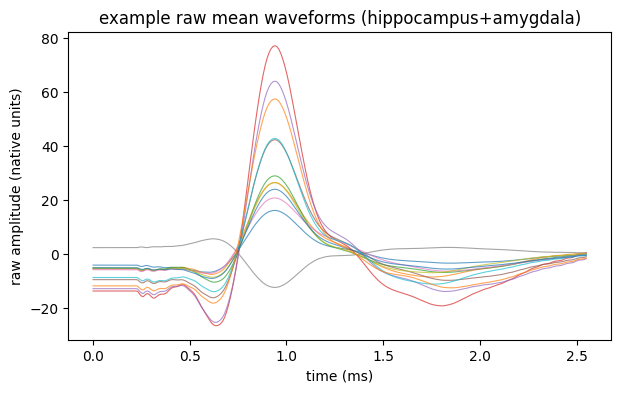

In [5]:
# [1.4] sanity plot: a few raw mean waveforms (native amplitude, unflipped)
fig, ax = plt.subplots(figsize=(7, 4))
t = (np.arange(X.shape[1]) / FS_HZ) * 1000.0
for i in range(min(12, len(X))):
    ax.plot(t, X[i], lw=0.8, alpha=0.7)
ax.set_xlabel('time (ms)'); ax.set_ylabel('raw amplitude (native units)')
ax.set_title(f'example raw mean waveforms ({REGION})'); plt.show()